In [446]:
import requests
import re
from bs4 import BeautifulSoup
from selenium import webdriver
import pandas as pd
from sklearn.model_selection import train_test_split
import sklearn.linear_model as lm
import sklearn.metrics as skm
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
import sklearn.preprocessing as pre

Set up BeautifulSoup

In [447]:
url = "https://www.eliteprospects.com/draft/nhl-entry-draft/2020"

response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')


Read the table from the provided eliteprospects year

In [448]:
def read_prospects(soup, year):
    outer_table = soup.find('div', id = 'drafted-players')
    table_div = outer_table.find('div', class_=lambda x: x and 'table-wizard' in x)
    table = table_div.find('table')
    rows = table.find_all('tr')[1:]
    data = []
    current_round = 0
    for row in rows:
        cols = row.find_all('td')
        if len(cols) == 1:
            current_round = int(re.findall(r'\d', cols[0].text.strip())[0])
            data.append([])
        elif cols:
            row_data = [col.text.strip() for col in cols]
            data[current_round - 1].append(row_data)
    draft_data = pd.DataFrame(columns=["Round", "Draft Position", "Player", "Position", "Team", "Seasons", "GP", "G", "A", "TP", "PIM", "Year"])
    current_round = 1
    for round in data:
        for player in round:
            print(player[3])
            try: # The 'Tyson Hinds' error
                if len(re.findall(r'\((.)\)', player[3])) > 0: # Fixing edge case from teams like the coyotes not following the rules
                    if player[6] == '-': # For Goalies
                        draft_entry = {
                            "Round": current_round,
                            "Draft Position": int(re.findall(r'\d+', player[0])[0]),
                            "Team": player[2],
                            "Player": player[3].split(" (")[0],
                            "Position": re.findall(r'\((.)\)', player[3])[0],
                            "Seasons": int(player[4]),
                            "GP": int(player[5]),
                            "G": 0,
                            "A": 0,
                            "TP": 0,
                            "PIM": 0,
                            "Year": year
                        }
                    elif player[5]:
                        draft_entry = {
                            "Round": current_round,
                            "Draft Position": int(re.findall(r'\d+', player[0])[0]),
                            "Team": player[2],
                            "Player": player[3].split(" (")[0],
                            "Position": re.findall(r'\((.)\)', player[3])[0],
                            "Seasons": int(player[4]),
                            "GP": int(player[5]),
                            "G": int(player[6]),
                            "A": int(player[7]),
                            "TP": int(player[8]),
                            "PIM": int(player[9]),
                            "Year": year
                        }
                    else: # For Players who have zero appearences
                        draft_entry = {
                            "Round": current_round,
                            "Draft Position": int(re.findall(r'\d+', player[0])[0]),
                            "Team": player[2],
                            "Player": player[3].split(" (")[0],
                            "Position": re.findall(r'\((.)\)', player[3])[0],
                            "Seasons": 0,
                            "GP": 0,
                            "G": 0,
                            "A": 0,
                            "TP": 0,
                            "PIM": 0,
                            "Year": year
                        }
                draft_data.loc[len(draft_data)] = draft_entry
            except:
                print(f"Error in {player[3]}'s format")
        current_round += 1
    return draft_data


In [449]:
drafts_by_year = {}
for year in range(2010,2022):
    url = "https://www.eliteprospects.com/draft/nhl-entry-draft/" + str(year)
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    drafts_by_year[year] = read_prospects(soup, year)

Taylor Hall (F)
Tyler Seguin (F)
Erik Gudbranson (D)
Ryan Johansen (F)
Nino Niederreiter (F)
Brett Connolly (F)
Jeff Skinner (F)
Alexander Burmistrov (F)
Mikael Granlund (F)
Dylan McIlrath (D)
Jack Campbell (G)
Cam Fowler (D)
Brandon Gormley (D)
Jaden Schwartz (F)
Derek Forbort (D)
Vladimir Tarasenko (F)
Joey Hishon (F)
Austin Watson (F)
Nick Bjugstad (F)
Beau Bennett (F)
Riley Sheahan (F)
Jarred Tinordi (D)
Mark Pysyk (D)
Kevin Hayes (F)
Quinton Howden (F)
Yevgeni Kuznetsov (F)
Mark Visentin (G)
Charlie Coyle (F)
Emerson Etem (F)
Brock Nelson (F)
Tyler Pitlick (F)
Jared Knight (F)
John McFarland (F)
Dalton Smith (F)
Ludvig Rensfeldt (F)
Alexander Petrovic (D)
Justin Faulk (D)
Jon Merrill (D)
Brett Bulmer (F)
Christian Thomas (F)
Patrik Nemeth (D)
Devante Smith-Pelly (F)
Brad Ross (D)
Sebastian Wännström (F)
Ryan Spooner (F)
Martin Marincin (D)
Tyler Toffoli (F)
Curtis Hamilton (F)
Calvin Pickard (G)
Connor Brickley (F)
Calle Järnkrok (F)
Phil Lane (F)
Mark Alt (D)
Justin Holl (D)
Petr

Make a data frame with the players sorted by round

In [450]:
players_by_round = {
    1: pd.DataFrame(columns=["Round", "Draft Position", "Player", "Position", "Team", "Seasons", "GP", "G", "A", "TP", "PIM", "Year"]), 
    2: pd.DataFrame(columns=["Round", "Draft Position", "Player", "Position", "Team", "Seasons", "GP", "G", "A", "TP", "PIM", "Year"]), 
    3: pd.DataFrame(columns=["Round", "Draft Position", "Player", "Position", "Team", "Seasons", "GP", "G", "A", "TP", "PIM", "Year"]), 
    4: pd.DataFrame(columns=["Round", "Draft Position", "Player", "Position", "Team", "Seasons", "GP", "G", "A", "TP", "PIM", "Year"]), 
    5: pd.DataFrame(columns=["Round", "Draft Position", "Player", "Position", "Team", "Seasons", "GP", "G", "A", "TP", "PIM", "Year"]),
    6: pd.DataFrame(columns=["Round", "Draft Position", "Player", "Position", "Team", "Seasons", "GP", "G", "A", "TP", "PIM", "Year"]),
    7: pd.DataFrame(columns=["Round", "Draft Position", "Player", "Position", "Team", "Seasons", "GP", "G", "A", "TP", "PIM", "Year"])
}
players_df = pd.DataFrame(columns=["Round", "Draft Position", "Player", "Position", "Team", "Seasons", "GP", "G", "A", "TP", "PIM", "Year"])
for i in drafts_by_year.keys():
    for j in range(0, len(drafts_by_year[i])):
        current_row = drafts_by_year[i].iloc[j]
        players_by_round[current_row["Round"]].loc[len(players_by_round[current_row["Round"]])] = current_row
        players_df.loc[len(players_df)] = current_row
print(players_df)

     Round Draft Position             Player Position                   Team  \
0        1              1        Taylor Hall        F        Edmonton Oilers   
1        1              2       Tyler Seguin        F          Boston Bruins   
2        1              3    Erik Gudbranson        D       Florida Panthers   
3        1              4      Ryan Johansen        F  Columbus Blue Jackets   
4        1              5  Nino Niederreiter        F     New York Islanders   
...    ...            ...                ...      ...                    ...   
2561     7            220       Taylor Makar        F     Colorado Avalanche   
2562     7            221        Tomas Machu        D     New York Islanders   
2563     7            222       Carl Lindbom        G   Vegas Golden Knights   
2564     7            223         Sam Lipkin        F        Arizona Coyotes   
2565     7            224     Niko Huuhtanen        F    Tampa Bay Lightning   

     Seasons   GP    G    A   TP  PIM  

Filter the results of the players by number of games played and print a bar graph to show the comparison between each round.

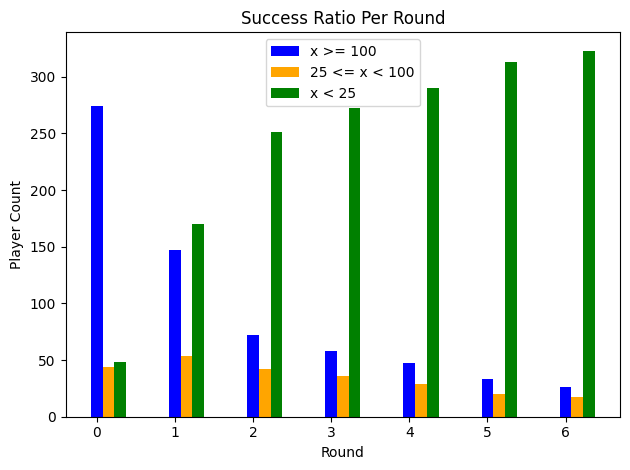

In [451]:
career_player, callup_player, bust_player = [], [], []
for i in players_by_round.keys():
    career_player.append(len(players_by_round[i][players_by_round[i]["GP"] >= 100]))
    callup_player.append(len(players_by_round[i][(players_by_round[i]["GP"] >= 25) & (players_by_round[i]["GP"] < 100)]))
    bust_player.append(len(players_by_round[i][players_by_round[i]["GP"] < 25]))

bar_width = 0.15
x = np.arange(len(players_by_round.keys()))  # base x positions
x_career = x
x_callup = x + bar_width
x_bust = x + 2 * bar_width
plt.bar(x_career, career_player, width = 0.15, label='x >= 100', color='blue')
plt.bar(x_callup, callup_player, width = 0.15, label='25 <= x < 100', color='orange')
plt.bar(x_bust, bust_player, width = 0.15, label='x < 25', color='green')

plt.xlabel('Round')
plt.ylabel('Player Count')
plt.title('Success Ratio Per Round')
plt.legend()

plt.tight_layout()
plt.show()

Create a linear regression formula for the players based on the limited data set

Mean Squared Error: 1467.6447149234366
R-squared: 0.9585244376736236
Coefficients: [-1.30638186  0.1133457  28.12766848 -0.09966096  0.47098369  0.37132274
  0.3129332  -0.13580167]
Intercept: 256.29733976733974


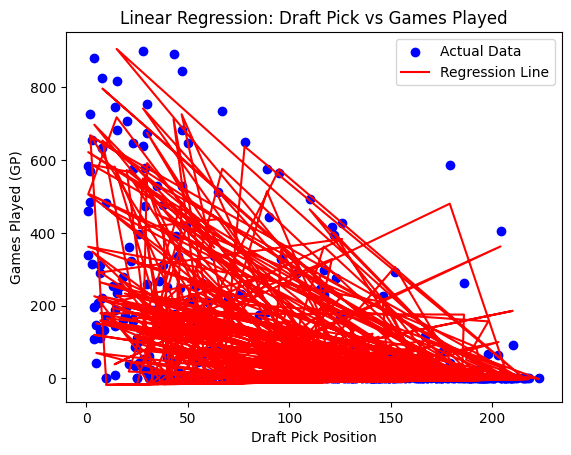

Round             0.989189
Draft Position    1.000000
Seasons          -0.503352
GP               -0.452849
G                -0.376717
A                -0.399424
TP               -0.398287
PIM              -0.382229
Year              0.027381
Name: Draft Position, dtype: float64
                                 OLS Regression Results                                
Dep. Variable:                     GP   R-squared (uncentered):                   0.900
Model:                            OLS   Adj. R-squared (uncentered):              0.900
Method:                 Least Squares   F-statistic:                              5510.
Date:                Mon, 16 Dec 2024   Prob (F-statistic):                        0.00
Time:                        12:08:20   Log-Likelihood:                         -10519.
No. Observations:                1844   AIC:                                  2.104e+04
Df Residuals:                    1841   BIC:                                  2.106e+04
Df Model:       

In [452]:
team_list = players_df['Team'].unique().tolist()
encoder = pre.LabelEncoder()
#players_df["Team"] = encoder.fit_transform(players_df['Team'])

skaters_df = players_df[players_df["Position"] != 'G']
goal_df = players_df[players_df["Position"] == 'G']
skaters_train, skaters_test, skater_y_train, skater_y_test = train_test_split(skaters_df.drop(columns=["GP"]), skaters_df["GP"], test_size=0.2, random_state=42)
model = lm.LinearRegression()

"""poly = pre.PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(skaters_train.drop(columns=["Player", "Position"]))"""

model.fit(skaters_train.drop(columns=["Player", "Position", "Team"]), skater_y_train)

y_pred = model.predict(skaters_test.drop(columns = ["Player", "Position", "Team"]))

mse = skm.mean_squared_error(skater_y_test, y_pred)
r2 = skm.r2_score(skater_y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Coefficients:", model.coef_)  # Includes higher-order terms
print("Intercept:", model.intercept_)
plt.scatter(skaters_test["Draft Position"], skater_y_test, color="blue", label="Actual Data")

# Regression line
plt.plot(skaters_test["Draft Position"], y_pred, color="red", label="Regression Line")

# Labels and legend
plt.xlabel("Draft Pick Position")
plt.ylabel("Games Played (GP)")
plt.title("Linear Regression: Draft Pick vs Games Played")
plt.legend()

plt.show()

correlation_with_draft = skaters_df.drop(columns = ["Player", "Position", "Team"]).corr()['Draft Position']
print(correlation_with_draft)

endog = pd.to_numeric(skater_y_train, errors='coerce')
exog = skaters_train[["G", "A", "TP", "PIM"]].apply(pd.to_numeric, errors='coerce')

model = sm.OLS(pd.to_numeric(skater_y_train, errors='coerce'), skaters_train[["G", "A", "TP", "PIM"]].apply(pd.to_numeric, errors='coerce')).fit()
print(model.summary())

Read the second data source which contains a higher number of statistics

In [ ]:
url = "https://www.hockey-reference.com/leagues/NHL_2024_skaters.html"
tables = pd.read_html(url)
print(f"Found {len(tables)} tables")
df = tables[0]
print(len(df.columns))
columns_titles = []
for i in df.columns:
    columns_titles.append(i[1])
df.columns = columns_titles
print(df.columns)

hr_goalie_df = pd.DataFrame(columns = ['Rk', 'Player', 'Age', 'Team', 'Pos', 'GP', 'GS', 'W', 'L', 'T/O', 'GA', 'Shots', 'SV', 'SV%', 'GAA', 'SO', 'MIN', 'QS', 'QS%', 'RBS', 'GA%-', 'GSAA', 'GAA/A', 'GPS', 'G', 'A', 'PTS', 'PIM', 'Awards'])
url = "https://www.hockey-reference.com/leagues/NHL_2024_goalies.html"
for year in range(2020, 2025):
    url = "https://www.hockey-reference.com/leagues/NHL_" + str(year) + "_goalies.html"
    tables = pd.read_html(url)
    print(f"Found {len(tables)} tables")
    tables[0].columns = ['Rk', 'Player', 'Age', 'Team', 'Pos', 'GP', 'GS', 'W', 'L', 'T/O', 'GA', 'Shots', 'SV', 'SV%', 'GAA', 'SO', 'MIN', 'QS', 'QS%', 'RBS', 'GA%-', 'GSAA', 'GAA/A', 'GPS', 'G', 'A', 'PTS', 'PIM', 'Awards']
    for i in range(len(tables[0])):
        row = tables[0].loc[i]
        #print(row)
        if row["Player"] in hr_goalie_df["Player"].values:
            for col in ['GP', 'GS', 'W', 'L', 'T/O', 'GA', 'Shots', 'SV', 'SO', 'MIN', 'QS']:
                hr_goalie_df.loc[hr_goalie_df["Player"] == row["Player"], col] += row[col]
        else:
            hr_goalie_df.loc[len(hr_goalie_df)] = row
            #hr_goalie_df = pd.concat([hr_goalie_df, tables[0]])


Found 2 tables
31
Found 2 tables
Found 2 tables
Found 2 tables
Found 2 tables
Found 2 tables


Merge the two tables

In [454]:
merged_df = pd.merge(skaters_df, df, on='Player', how='left')
forward_df = merged_df[merged_df['Position'] == 'F']
defender_df = merged_df[merged_df['Position'] == 'D']
merge_goalies = pd.merge(hr_goalie_df, goal_df, on = 'Player', how='left')
print(merge_goalies["Team_y"].unique().tolist())
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(merge_goalies[merge_goalies['Team_y'] == 'Anaheim Ducks'])


['Winnipeg Jets', nan, 'Carolina Hurricanes', 'Anaheim Ducks', 'St. Louis Blues', 'New Jersey Devils', 'Philadelphia Flyers', 'Detroit Red Wings', 'Nashville Predators', 'Pittsburgh Penguins', 'Columbus Blue Jackets', 'Washington Capitals', 'Buffalo Sabres', 'Vancouver Canucks', 'Dallas Stars', 'Ottawa Senators', 'Boston Bruins', 'Calgary Flames', 'Phoenix Coyotes', 'Arizona Coyotes', 'Minnesota Wild', 'Colorado Avalanche', 'Toronto Maple Leafs', 'Montréal Canadiens', 'New York Islanders', 'Florida Panthers', 'Los Angeles Kings', 'Edmonton Oilers', 'Tampa Bay Lightning', 'Chicago Blackhawks']
        Rk             Player   Age Team_x Pos   GP_x     GS      W      L  \
3      3.0  Frederik Andersen  30.0    TOR   G  178.0  175.0  111.0   48.0   
5      5.0        John Gibson  26.0    ANA   G  241.0  238.0   74.0  129.0   
156  103.0   Olle Eriksson Ek  23.0    ANA   G    1.0    1.0    0.0    0.0   

      T/O     GA   Shots      SV    SV%   GAA    SO  \
3    14.0  434.0  4935.0  4501.0